# 한국어로 QnA(question Answering)하기

In [1]:
!pip install customized_konlpy

In [2]:
# 다른 형태소 분석기 사용해보자(Twitter)
from ckonlpy.tag import Twitter
from tensorflow.keras.utils import get_file
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np
from nltk import FreqDist
from functools import reduce
import os
import re
import matplotlib.pyplot as plt

In [3]:
# 파일경로 설정
train_file = os.path.join('/content/drive/MyDrive/Colab Notebooks/dataset/qa1_single-supporting-fact_train_kor.txt')
test_file = os.path.join('/content/drive/MyDrive/Colab Notebooks/dataset/qa1_single-supporting-fact_test_kor.txt')

In [4]:
# 보자
i = 0
lines = open(train_file, 'rb')

for line in lines :
    line = line.decode('utf-8').strip()
    i += 1
    print(line)
    if i == 20 :
        break

1 필웅이는 화장실로 갔습니다.
2 은경이는 복도로 이동했습니다.
3 필웅이는 어디야? 	화장실	1
4 수종이는 복도로 복귀했습니다.
5 경임이는 정원으로 갔습니다.
6 수종이는 어디야? 	복도	4
7 은경이는 사무실로 갔습니다.
8 경임이는 화장실로 뛰어갔습니다.
9 수종이는 어디야? 	복도	4
10 필웅이는 복도로 갔습니다.
11 수종이는 사무실로 가버렸습니다.
12 수종이는 어디야? 	사무실	11
13 은경이는 정원으로 복귀했습니다.
14 은경이는 침실로 갔습니다.
15 경임이는 어디야? 	화장실	8
1 경임이는 사무실로 가버렸습니다.
2 경임이는 화장실로 이동했습니다.
3 경임이는 어디야? 	화장실	2
4 필웅이는 침실로 이동했습니다.
5 수종이는 복도로 갔습니다.


In [5]:
def read_data(dir) :

    stories, questions, answers = [], [], []
    story_temp = []
    lines = open(dir, 'rb')

    for line in lines :
        line = line.decode('UTF-8') # b' 분리
        line = line.strip() # \n제거
        idx, text = line.split(" ", 1) # 맨 앞에있는 id number 제거

        if int(idx) ==1 :
            story_temp = []

        if '\t' in text : # 현재 줄이 질문(tab), 답변(tqb) 일때
            question, answer, _ = text.split('\t')
            stories.append([x for x in story_temp if x])
            questions.append(question)
            answers.append(answer)
        
        else :
            story_temp.append(text)

    lines.close()
    
    return stories, questions, answers

In [6]:
train_data = read_data(train_file)
test_data = read_data(test_file)

In [7]:
train_stories, train_questions, train_answers = read_data(train_file)
test_stories, test_questions, test_answers = read_data(test_file)

In [8]:
print('훈련용 스토리 갯수 :', len(train_stories))
print('훈련용 질문의 갯수 ;', len(train_questions))
print('훈련용 답변의 갯수 :', len(train_answers))
print()
print('테스트용 스토리 갯수 :', len(test_stories))
print('테스트용 질문의 갯수 :', len(test_questions))
print('테스트용 답변의 갯수 :', len(test_answers))

훈련용 스토리 갯수 : 10000
훈련용 질문의 갯수 ; 10000
훈련용 답변의 갯수 : 10000

테스트용 스토리 갯수 : 1000
테스트용 질문의 갯수 : 1000
테스트용 답변의 갯수 : 1000


In [9]:
# 잘 들어갔는지 임의의 걸로 출력해보자
train_stories[3678]

['필웅이는 사무실로 복귀했습니다.',
 '은경이는 화장실로 가버렸습니다.',
 '수종이는 사무실로 갔습니다.',
 '수종이는 복도로 가버렸습니다.',
 '수종이는 사무실로 이동했습니다.',
 '수종이는 정원으로 뛰어갔습니다.',
 '은경이는 침실로 복귀했습니다.',
 '수종이는 화장실로 복귀했습니다.']

In [10]:
train_questions[3678]

'은경이는 어디야? '

In [11]:
train_answers[3678]

'침실'

## tokenize & vocab

In [12]:
twitter = Twitter()

/usr/local/lib/python3.7/dist-packages/konlpy/tag/_okt.py:16: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


In [13]:
def tokenize(sent):
    # return [str(x).strip() for x in re.split('(\W+)?', sent) if str(x).strip()]
    return twitter.morphs(sent)

def preprocess_data(train_data, test_data):
    counter = FreqDist()

    # 두 문장의 story를 하나의 문장으로 통합하는 함수
    flatten = lambda data: reduce(lambda x, y: x+y, data)

    # 각 샘플의 길이를 저장하는 리스트
    story_len = []
    question_len = []
    
    for stories, questions, answers in [train_data, test_data]:
        for story in stories:
            stories = tokenize(flatten(story))
            story_len.append(len(stories))
            for word in stories: # 단어 집합에 단어 추가
                counter[word] += 1

        for question in questions:
            question=tokenize(question)
            question_len.append(len(question))
            for word in question:
                counter[word]+= 1

        for answer in answers:
            answer = tokenize(answer)
            for word in answer:
                counter[word] += 1

        #단어 집합 생성
        word2idx = {word : (idx +1) for idx, (word, _) in enumerate(counter.most_common())}
        idx2word = {idx:word for word, idx in word2idx.items()}

        story_max_len = np.max(story_len)
        question_max_len = np.max(question_len)

        return word2idx, idx2word, story_max_len, question_max_len

In [14]:
word2idx, idx2word, story_max_len, question_max_len = preprocess_data(train_data, test_data)

In [15]:
print(word2idx) # 이름이 분리되어버리는데.... 

{'는': 1, '.': 2, '로': 3, '이': 4, '했습니다': 5, '으로': 6, '은': 7, '경이': 8, '필웅이': 9, '경': 10, '임': 11, '수종': 12, '이동': 13, '뛰어갔습니다': 14, '가버렸습니다': 15, '복귀': 16, '화장실': 17, '복도': 18, '갔습니다': 19, '정원': 20, '사무실': 21, '부엌': 22, '침실': 23, '어디': 24, '야': 25, '?': 26}


In [16]:
# dictionary를 추가해주자
twitter.add_dictionary('은경이', 'Noun')
twitter.add_dictionary('경임이', 'Noun')
twitter.add_dictionary('수종이', 'Noun')

In [17]:
word2idx, idx2word, story_max_len, question_max_len = preprocess_data(train_data, test_data)

In [18]:
print(word2idx) # 잘 나왔구만

{'는': 1, '.': 2, '로': 3, '했습니다': 4, '으로': 5, '은경이': 6, '필웅이': 7, '경임이': 8, '수종이': 9, '이동': 10, '뛰어갔습니다': 11, '가버렸습니다': 12, '복귀': 13, '화장실': 14, '복도': 15, '갔습니다': 16, '정원': 17, '사무실': 18, '부엌': 19, '침실': 20, '어디': 21, '야': 22, '?': 23}


In [19]:
# 단어 크기 정리하자
vocab_size = len(word2idx) + 1
print(vocab_size)

24


In [20]:
print('스토리의 최대 길이 :', story_max_len)
print('질문의 최대 길이 :', question_max_len)

스토리의 최대 길이 : 70
질문의 최대 길이 : 5


In [21]:
# 벡터화 시키는 함수
def vectorize(data, word2idx, story_maxlen, question_maxlen) :
    Xs, Xq, y = [], [], []
    flatten = lambda data : reduce(lambda x, y : x+y, data)

    stories, questions, answers = data
    for story, question, answer in zip(stories, questions, answers) :
        xs = [word2idx[w] for w in tokenize(flatten(story))]
        xq = [word2idx[w] for w in tokenize(flatten(question))]
        Xs.append(xs)
        Xq.append(xq)
        y.append(word2idx[answer])

    return pad_sequences(Xs, maxlen=story_maxlen), \
    pad_sequences(Xq, maxlen=question_maxlen), \
    to_categorical(y, num_classes=len(word2idx)+1)

In [22]:
xstrain, xqtrain, ytrain = vectorize(train_data, word2idx, story_max_len, question_max_len)
xstest, xqtest, ytest = vectorize(test_data, word2idx, story_max_len, question_max_len)


In [23]:
print(xstrain.shape, xqtrain.shape, ytrain.shape, xstest.shape, xqtest.shape, ytest.shape)

(10000, 70) (10000, 5) (10000, 24) (1000, 70) (1000, 5) (1000, 24)


## 메모리 네트워크 만들기

![](https://wikidocs.net/images/page/82475/memn.PNG)

In [24]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Permute, dot, add, concatenate
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Activation

In [25]:
train_epochs = 120
batch_size = 32
embed_size = 50
lstm_size = 64
dropout_rate = 0.3


In [26]:
#입력받을 변수
input_sequence = Input((story_max_len,))
question = Input((question_max_len,))

print('Stories :', input_sequence)
print('Question:', question)

Stories : KerasTensor(type_spec=TensorSpec(shape=(None, 70), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
Question: KerasTensor(type_spec=TensorSpec(shape=(None, 5), dtype=tf.float32, name='input_2'), name='input_2', description="created by layer 'input_2'")


In [27]:
# Embedding A
input_encoder_m = Sequential()
input_encoder_m.add(Embedding(input_dim=vocab_size,
                              output_dim=embed_size))
input_encoder_m.add(Dropout(dropout_rate))

# output =  샘플의 수, 문장의 최대길이, 임베딩 벡터의 차원

# Embedding C
# 임베딩벡터의 차원을 질문의 최대길이로
input_encoder_c = Sequential()
input_encoder_c.add(Embedding(input_dim=vocab_size,
                              output_dim=question_max_len))
input_encoder_c.add(Dropout(dropout_rate))
# output = 샘플의 수, 문장의 최대길이, 질문의 최대길이(임베딩벡터의 차원)

In [28]:
# Embedding B (질문)
question_encoder = Sequential()
question_encoder.add(Embedding(input_dim=vocab_size,
                               output_dim=embed_size,
                               input_length=question_max_len))
question_encoder.add(Dropout(dropout_rate))
# output 샘플의 수, 질문의 최대길이, 임베딩 벡터의 차원

In [29]:
# 임베딩하는 과정
input_encoder_m = input_encoder_m(input_sequence)
input_encoder_c = input_encoder_c(input_sequence)
question_encoded = question_encoder(question)

print('Input encoded m', input_encoder_m)
print('Input encoded c', input_encoder_c)
print('Question encoded', question_encoded)

Input encoded m KerasTensor(type_spec=TensorSpec(shape=(None, 70, 50), dtype=tf.float32, name=None), name='sequential/dropout/Identity:0', description="created by layer 'sequential'")
Input encoded c KerasTensor(type_spec=TensorSpec(shape=(None, 70, 5), dtype=tf.float32, name=None), name='sequential_1/dropout_1/Identity:0', description="created by layer 'sequential_1'")
Question encoded KerasTensor(type_spec=TensorSpec(shape=(None, 5, 50), dtype=tf.float32, name=None), name='sequential_2/dropout_2/Identity:0', description="created by layer 'sequential_2'")


In [30]:
#유사도를 구해보자
match = dot([input_encoder_m, question_encoded], axes=-1, normalize=False)
match = Activation('softmax')(match)
print('Match shape', match)

response = add([match, input_encoder_c])
response = Permute((2, 1))(response)
print('Response shape', response)

# 질문이랑 응답이랑 concat
answer = concatenate([response, question_encoded])
print('Answer shape', answer)

answer = LSTM(lstm_size)(answer)
answer = Dropout(dropout_rate)(answer)
answer = Dense(vocab_size)(answer)
answer = Activation('softmax')(answer)

Match shape KerasTensor(type_spec=TensorSpec(shape=(None, 70, 5), dtype=tf.float32, name=None), name='activation/Softmax:0', description="created by layer 'activation'")
Response shape KerasTensor(type_spec=TensorSpec(shape=(None, 5, 70), dtype=tf.float32, name=None), name='permute/transpose:0', description="created by layer 'permute'")
Answer shape KerasTensor(type_spec=TensorSpec(shape=(None, 5, 120), dtype=tf.float32, name=None), name='concatenate/concat:0', description="created by layer 'concatenate'")


In [31]:
# compile
model =Model([input_sequence, question], answer)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
print(model.summary())

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 70)]         0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 5)]          0                                            
__________________________________________________________________________________________________
sequential (Sequential)         (None, None, 50)     1200        input_1[0][0]                    
__________________________________________________________________________________________________
sequential_2 (Sequential)       (None, 5, 50)        1200        input_2[0][0]                    
______________________________________________________________________________________________

In [32]:
history = model.fit([xstrain, xqtrain],
                    ytrain, batch_size, train_epochs,
                    validation_data = ([xstest, xqtest], ytest))

# 모델 저장
model.save('model.h5')

Epoch 1/120
313/313 [==============================] - 7s 12ms/step - loss: 1.9448 - acc: 0.1692 - val_loss: 1.8082 - val_acc: 0.1900
Epoch 2/120
313/313 [==============================] - 3s 9ms/step - loss: 1.7652 - acc: 0.2168 - val_loss: 1.6305 - val_acc: 0.3160
Epoch 3/120
313/313 [==============================] - 3s 9ms/step - loss: 1.5654 - acc: 0.3627 - val_loss: 1.4598 - val_acc: 0.4190
Epoch 4/120
313/313 [==============================] - 3s 9ms/step - loss: 1.4591 - acc: 0.4292 - val_loss: 1.4784 - val_acc: 0.4300
Epoch 5/120
313/313 [==============================] - 3s 9ms/step - loss: 1.4218 - acc: 0.4512 - val_loss: 1.3732 - val_acc: 0.4730
Epoch 6/120
313/313 [==============================] - 3s 9ms/step - loss: 1.3876 - acc: 0.4608 - val_loss: 1.3533 - val_acc: 0.4650
Epoch 7/120
313/313 [==============================] - 3s 9ms/step - loss: 1.3693 - acc: 0.4741 - val_loss: 1.3276 - val_acc: 0.4840
Epoch 8/120
313/313 [==============================] - 3s 9ms/step -

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [33]:
ytest.shape

(1000, 24)

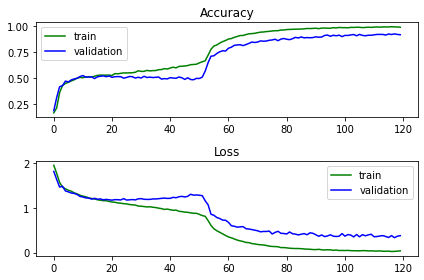

In [34]:
plt.subplot(211)
plt.title("Accuracy")
plt.plot(history.history["acc"], color='g', label="train")
plt.plot(history.history["val_acc"], color='b', label="validation")
plt.legend(loc="best")

plt.subplot(212)
plt.title("Loss")
plt.plot(history.history["loss"], color="g", label='train')
plt.plot(history.history["val_loss"], color='b', label="validation")
plt.legend(loc="best")

plt.tight_layout()
plt.show()

# labels
ytest = np.argmax(ytest, axis=1) # (1000,)

# get predictions
ytest_ = model.predict([xstest, xqtest])
ytest_ = np.argmax(ytest_, axis=1)

In [35]:
# 실제값과 예측값이 잘 맞는지
num_display = 30
print("{:18}|{:5}|{}".format('질문', '실제값', '예측값'))
print(39*'_')

for i in range(num_display):
    question = ' '.join([idx2word[x] for x in xqtest[i].tolist()])
    label = idx2word[ytest[i]]
    prediction = idx2word[ytest_[i]]
    print("{:20}|{:7}|{}".format(question, label, prediction))

질문                |실제값  |예측값
_______________________________________
은경이 는 어디 야 ?        |복도     |복도
필웅이 는 어디 야 ?        |화장실    |화장실
경임이 는 어디 야 ?        |부엌     |부엌
경임이 는 어디 야 ?        |복도     |복도
경임이 는 어디 야 ?        |부엌     |부엌
경임이 는 어디 야 ?        |복도     |복도
경임이 는 어디 야 ?        |정원     |정원
수종이 는 어디 야 ?        |복도     |복도
경임이 는 어디 야 ?        |사무실    |정원
수종이 는 어디 야 ?        |사무실    |화장실
필웅이 는 어디 야 ?        |부엌     |부엌
필웅이 는 어디 야 ?        |정원     |정원
수종이 는 어디 야 ?        |사무실    |사무실
필웅이 는 어디 야 ?        |침실     |침실
필웅이 는 어디 야 ?        |침실     |침실
은경이 는 어디 야 ?        |부엌     |부엌
은경이 는 어디 야 ?        |정원     |정원
은경이 는 어디 야 ?        |부엌     |부엌
수종이 는 어디 야 ?        |사무실    |부엌
은경이 는 어디 야 ?        |부엌     |화장실
필웅이 는 어디 야 ?        |복도     |복도
은경이 는 어디 야 ?        |사무실    |사무실
은경이 는 어디 야 ?        |사무실    |사무실
경임이 는 어디 야 ?        |복도     |복도
수종이 는 어디 야 ?        |침실     |침실
경임이 는 어디 야 ?        |침실     |침실
필웅이 는 어디 야 ?        |침실     |침실
수종이 는 어디 야 ?        |부엌     |부엌
수종이 는 어디 야 ?        |부엌     |

# Transformer

- seq2seq 모델은 encoder-decoder로 구성됨

- 기존 seq2seq모델의 한계 : 입력시퀀스를 하나의 벡터표현ㅇ로 압축하고 디코더가 다시 시뭔스를 만드는데 기울기가 소실되는 단점 존재한다.

In [36]:
# parpmeter
d_model = 512
num_layer = 6
num_head = 8
d_ff = 2048

![](https://wikidocs.net/images/page/31379/transformer1.PNG)

![](https://wikidocs.net/images/page/31379/transformer2.PNG)

![](https://wikidocs.net/images/page/31379/transformer4_final_final_final.PNG)

### 포지셔널 인코딩
![](https://wikidocs.net/images/page/31379/transformer5_final_final.PNG)

![](https://wikidocs.net/images/page/31379/transformer6_final.PNG)

$$PE_(pose, 2i) = sin(pos/1000^{2i/d_{model}})$$
$$PE_(pose, 2i+1) = cos(pos/1000^{2i/d_{model}})$$

![](https://wikidocs.net/images/page/31379/transformer7.PNG)

- pos : 입력 문장에서의 임베딩 벡터의 위치 
- i : 임베딩 벡터 내의 차원의 인덱스를 의미  
(pos, 2i) -->사인함수, (pos, 2i+1) --> 코사인함수

In [37]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [38]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(position, d_model)
    def get_angles(self, position, i, d_model):
        angles = 1/tf.pow(10000, (2*(i//2))/tf.cast(d_model, tf.float32))
        return position * angles
    
    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(
            position= tf.range(position, dtype=tf.float32)[:, tf.newaxis],
            i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
            d_model = d_model
        )

        sines = tf.math.sin(angle_rads[:, 0::2])
        cosines = tf.math.cos(angle_rads[:, 1::2])

        angle_rads = np.zeros(angle_rads.shape)
        angle_rads[:, 0::2] = sines
        angle_rads[:, 1::2] = cosines
        pos_encoding = tf.constant(angle_rads)
        pos_encoding = pos_encoding[tf.newaxis, ...] ### [1, :, :, :, ..... 라는거]

        print(pos_encoding.shape)
        return tf.cast(pos_encoding, tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

In [ ]:
# 50x 128크기를 가지는 포지셔널인코딩 행렬을 시각화해서 어떤 형태를 가지는지 봅시다.
# 입력 문장의 단어가 50, 각 단어가 128차원의 임베딩 벡터를 가질 때 사용할 수 있는 행렬

sample_pos_encoding = PositionalEncoding(50, 128)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap="RdBu")
plt.xlabel('Depth')
plt.xlim((0,128))
plt.ylabel('Position')
plt.colorbar()
plt.show()

### 어텐션

![](https://wikidocs.net/images/page/31379/attention.PNG)

- 인코더 셀프 어텐션 : Query = Key = value
- 디코더 마스크드 셀프 어텐션 : Query = Key = value
- 디코더의 인코더-디코더 어텐션 : Query (디코더 벡터)  
key = value (인코더 벡터)

![](https://wikidocs.net/images/page/31379/transformer_attention_overview.PNG)

### 인코더

![](https://wikidocs.net/images/page/31379/transformer9_final_ver.PNG)

### 셀프 어텐션

- Query(쿼리)에 대해서 모든 키(Key)의 유사도

![](https://wikidocs.net/images/page/22893/%EC%BF%BC%EB%A6%AC.PNG)

seq2seq에서 Q,K,V
- Query : t시점의 디코더 셀에서의 은닉상태
- Key : 모든 시점의 인코더 셀의 은닉상태
- values : 모든 시점의 인코더 셀의 은닉상태

transformer에서 Q,K,V
- Query : 입력 문장의 모든 단어 벡터들
- Key : 입력 문장의 모든 단어 벡터들
- Value : 입력 문장의 모든 단어 벡터들

![](https://wikidocs.net/images/page/31379/transformer10.png)

### Q, K, V 벡터 얻기

![](https://wikidocs.net/images/page/31379/transformer11.PNG)

- $d_{model}$ = 512
- $num_heads$ = 8
- 512/8 = 64

### 스케일드 닷 프로덕트 어텐션

![](https://wikidocs.net/images/page/31379/transformer13.PNG)

![](https://wikidocs.net/images/page/31379/transformer14_final.PNG)

### 스케일드 닷- 프로덕트 어텐션 구현하기

In [ ]:
def scaled_dot_product_attention(query, key, value, mask):
  #query 크기 : (batch_size, num_heads, query의 문장 길이, d_model/num_heads)
  # key 크기 : (batch_size, num_heads, key의 문장 길이, d_model/num_heads)
  # value 크기 : (batch_size, num_heads, value의 문장 길이, d_model/num_heads)
  # padding mask : (batch_size, 1, 1, key의 문장 길이)

  # Q와 K의 곱
  matmul_qk = tf.matmul(query, key, transpose_b = True)

  # 스케일링
  # dk의 루트값으로 나눠준다.
  depth = tf.cast(tf.shape(key)[-1], tf.float32)
  logits = matmul_qk / tf.math.sqrt(depth)

  # 마스킹 어텐션 스코어 행렬의 마스킹 할 위치에 매우 작은 음수값을 넣는다.
  # 매우 작은 값이므로 소프트맥스 함수를 지나면 행렬의 해당 위치의 값은 0이 된다.
  if mask is not None:
    logits += (mask * -1e9)

  # 소프트맥스 함수는 마지막 차원인 key의 문장 길이 방향으로 수행된다.
  # attention weight : (batch_size, num_heads, query의 문장 길이, key의 문장 길이)
  attention_weight = tf.nn.softmax(logits, axis=-1)

  # output : (batch_size, num_heads, query의 문장 길이 , d_model/num_heads)
  output = tf.matmul(attention_weight, value)

  return output, attention_weight

In [ ]:
# scaled_dot_product_attention함수가 정상적으로 작동하는지 테스트!
import numpy as np
import tensorflow as tf
np.set_printoptions(suppress=True)
temp_k = tf.constant([[10, 0, 0],
                      [0, 10, 0],
                      [0, 0, 10],
                      [0, 0, 10]], dtype=tf.float32) # (4,3)
temp_v = tf.constant([[   1,0],
                     [  10,0],
                     [ 100,5],
                     [1000,6]], dtype=tf.float32) # (4,2)
temp_q = tf.constant([[0, 10, 0]],dtype=tf.float32) # (1,3)

In [ ]:
# 함수 실행
temp_out, temp_attn = scaled_dot_product_attention(temp_q, temp_k, temp_v, None)
print(temp_attn) # 어텐션 분포 (어텐션 가중치의 낭려)
print(temp_out) #어텐션 값

In [ ]:
temp_k = tf.constant([[10, 0, 0],
                      [0, 10, 0],
                      [0, 0, 10],
                      [0, 0, 10]], dtype=tf.float32) # (4,3)
temp_v = tf.constant([[   1,0],
                     [  10,0],
                     [ 100,5],
                     [1000,6]], dtype=tf.float32) # (4,2)
temp_q = tf.constant([[0, 0, 10]],dtype=tf.float32) # (1,3)

In [ ]:
temp_out, temp_attn = scaled_dot_product_attention(temp_q, temp_k, temp_v, None)
print(temp_attn)
print(temp_out)

In [ ]:
temp_k = tf.constant([[10, 0, 0],
                      [0, 10, 0],
                      [0, 0, 10],
                      [0, 0, 10]], dtype=tf.float32) # (4,3)
temp_v = tf.constant([[   1,0],
                     [  10,0],
                     [ 100,5],
                     [1000,6]], dtype=tf.float32) # (4,2)
temp_q = tf.constant([[0, 0, 10],
                     [0, 10, 0],
                     [10, 10, 0]], dtype = tf.float32) # (3,3)

In [ ]:
temp_out, temp_attn = scaled_dot_product_attention(temp_q, temp_k, temp_v, None)
print(temp_attn)
print(temp_out)

### 멀티 헤드 어텐션

![](https://wikidocs.net/images/page/31379/transformer17.PNG)

병렬 어텐션의 효과는?  
머리가 여러개이기 때문에, 여러 시점에서 상대방을 볼 수 있다.

1. $W_Q, W_k, W_v$에 해당하는 $d_{model}$크기의 밀집층(Dense layer)을 지남
2. 지정된 헤드 수 (num_heads)만큼 나눈다.
3. 스케일드 닷 프로덕트 어텐션
4. 나눠졌던 헤드들을 연결한다.
5. W_0에 해당하는 밀집층을 지나게 된다.

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, name="multi_head_attention"):
    super(MultiHeadAttention, self).__init__(name=name)
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    # d_model을 num_heads로 나눈 값
    # 논문 기준 64
    self.depth = d_model//self.num_heads

    # WQ, WK, WV에 해당하는 밀집층 정의
    self.query_dense = tf.keras.layers.Dense(units=d_model)
    self.key_dense = tf.keras.layers.Dense(units=d_model)
    self.value_dense = tf.keras.layers.Dense(units=d_model)

    #WQ에 해당하는 밀집층 정의
    self.dense = tf.keras.layers.Dense(units=d_model)

    #num_heads개수만큼 q,k,v를 split하는 함수

  def split_heads(self, inputs, batch_size):
    inputs = tf.reshape(
        inputs, shape=(batch_size, -1, self.num_heads, self.depth)
    )
    return tf.transpose(inputs, perm=[0,2,1,3])

  def call(self, inputs):
    query, key, value, mask = inputs['query'], inputs['key'], inputs['value'], inputs['mask']
    batch_size = tf.shape(query)[0]

    # 1. Wq, wk, wv에 해당하는 밀집층 지나기
    # q : (batch_size, query의 문장 길이, d_model)
    # k : (batch_size, key의 문장 길이, d_model)
    # v : (batch_size, value의 문장 길이, d_model)

    # 참고 ** 인코더 (k, v)- 디코터(q) 어텐션에서는 query길이와 key, value의 길이는 다를 수 있다.
    query = self.query_dense(query)
    key = self.key_dense(key)
    value = self.value_dense(value)

    # 2. 헤드 나누기
    # q : (batch_size, num_heads, query의 문장 길이, d_model/num_heads)
    # k : (batch_size, num_heads, key의 문장 길이, d_model/num_heads)
    # v : (batch_size, num_heads, value의 문장 길이, d_model/num_heads)

    query = self.split_heads(query, batch_size)
    key = self.split_heads(key, batch_size)
    value = self.split_heads(value, batch_size)

    #3. 스케일드 닷 프로덕트 어텐션
    # (batch_size, num_heads, query의 문장 길이, d_model/num_heads)
    scaled_attention, _=scaled_dot_product_attention(query, key, value, mask)
    # (batch_size, query의 문장 길이, num_heads, d_model/num_heads)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

    # 4. 헤드 연결
    # (batch_size, query의 문장 길이, d_model)
    concat_attention = tf.reshape(scaled_dot_product_attention, (batch_size, -1, self.d_model))

    # 5. wo에 해당하는 밀집층 지나기
    # (batch_size, query의 문장 길이, d_model)
    outputs = self.dense(concat_attention)

    return outputs

### 패딩 마스크(Padding Mask)

![](https://wikidocs.net/images/page/31379/pad_masking11.PNG)

![](https://wikidocs.net/images/page/31379/pad_masking2.PNG)

![](https://wikidocs.net/images/page/31379/softmax.PNG)

In [ ]:
def create_padding_mask(x):
  mask = tf.cast(tf.math.equal(x, 0), tf.float32)
  # (batch_size, 1, 1, key의 문장 길이)
  return mask[:, tf.newaxis, tf.newaxis, :]

In [ ]:
print(create_padding_mask(tf.constant([[1, 21, 777, 0, 0]])))

### 포지션-와이드 피드 포워드 신경망

$$ FFNN(x) = MAX(0, xW_1 + B_1)W_2 + b_2$$

![](https://wikidocs.net/images/page/31379/positionwiseffnn.PNG)

```
outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention)
outpus = tf.kears.layers.Dense(units=d_model)(outpus)
```

### 잔차 연결과 층 정규화 (Layer Normalizarion)

잔차 연결 (Residual connection)  
H(x) = x + F(x)

![](https://wikidocs.net/images/page/31379/transformer22.PNG)

H(x) = x + Sublayer(x)  
LN = LayerNorm(x + Sublayer(x))

### 인코더 구현하기

In [ ]:
def encoder_layer(dff, d_model, num_heads, dropout, name="encoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")

  # 인코더는 패딩 마스크 사용
  padding_mask = tf.keras.Input(shape=(1,1,None), name="padding_mask")

  # 멀티-헤드 어텐션 (첫번째 서브층 /셀프 어텐션)
  attention = MultiHeadAttention(
      d_model, num_heads, name="attention")({
          'query': inputs, 'key': inputs, 'value': inputs, # Q = K = V
          'mask': padding_mask # 패딩 마스크 사용
      })

  # 드롭아웃 + 잔차 연결과 층 정규화
  attention = tf.keras.layers.Dropout(rate=dropout)(attention)
  attention = tf.keras.layers.LayerNormalization(
      epsion=1e-6)(inputs + attention)

  # 포지션 와이즈 피드 포워드 신경망 (두번째 서브층)
  outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 드롭아웃 + 잔차 연결과 층 정규화
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6(attention + outputs))

  return tf.keras.Model(inputs=[inputs, padding_mask], outputs=outputs, name=name)

### 인코더 쌓기

In [ ]:
def encoder(vocab_size, num_layers, dff, d_model, num_heads, dropout, name="encoder"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 인코더는 패딩마스크 사용
  padding_mask = tf.keras.Input(shape=(1, 1, None), name = "padding_mask")

  #포지셔널 인코딩 + 드롭아웃
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
  embeddings = PositionalEncoding(vocab_size, d_model)
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # 인코딩를 num_layer개 쌓기
  for i in range(num_layers):
    outputs = encoder_layer(dff=dff, d_model=d_model, num_heads=num_heads,
        dropout=dropout, name="encoder_layer_{}".format(i),
    )([outputs, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name
  )

### 디코더의 첫번째 서브층 : self어텐션과 룩-헤드마스크

![](https://wikidocs.net/images/page/31379/decoder.PNG)

![](https://wikidocs.net/images/page/31379/%EB%A3%A9%EC%96%B4%ED%97%A4%EB%93%9C%EB%A7%88%EC%8A%A4%ED%81%AC.PNG)

- 인코더에 있는 self어텐션 : 패딩마스크전달
- 디코더와 첫번째 서브층인 masked self attention : 룩-어헤드 마스크전달
- 디코더의 두번째 서브층인 인코더-디코더 어텐션 : 패딩마스크전달

In [ ]:
# 디코더의 첫번째 서브층(sublayer)에서 미래 토큰을 mask하는 함수
def create_look_ahead_mask(x):
  seq_len = tf.shape(x)[1]
  look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
  padding_mask = create_padding_mask(x) #패딩 마스크 포함
  return tf.maximum(look_ahead_mask, padding_mask)

In [ ]:
print(create_look_ahead_mask(tf.constant([[1,2,0,4,5]])))

### 디코더의 두번째 서브층 : 인코더-디코더 어텐션

다시한번 서브층에서 Q, K, V관계를 정리하자
- 인코더의 첫번째 서브층 : Query = Key = Value
- 디코더의 첫번째 서브층 : Query = Key = Value
- 디코더의 두번째 서브층 : Query (디코더행렬) // key=value (인코더행렬)

### 디코더 구현하기

In [ ]:
def decoder_layer(dff, d_model, num_heads, dropout, name="decoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outpus")

  # 룩어헤드 마스크(첫번째 서브층)
  look_ahead_mask = tf.keras.Input(
      shape = (1, None, None), name="look_ahead_mask"
  )

  # 패딩마스크 (두번째 서브층)
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  # 멀티-헤드 어텐션 (첫번째 서브층 / 마스크드 셀프 어텐션)
  attention1 = MultiHeadAttention(
      d_model, num_heads, name="attention_1")(inputs={
          'query':inputs, 'key':inputs, 'value':inputs, # Q= K = V
          'mask' : look_ahead_mask
      })
  
  # 잔차 연결과 층 정규화
  attention1 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention1+inputs)
  
  # 멀티 헤드 어텐션 (두번째 서브층/ 디코더-인코더 어텐션)
  attention2 = MultiHeadAttention(
      d_model, num_heads, name="attention_2")(inputs={
          'query':attention1, 'key' : enc_outputs, 'value': enc_outputs, # Q=K=V
          'mask' : padding_mask # 패딩 마스크
      })

  # 드롭아웃 + 잔차 연결과 층 정규화
  attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
  attention2 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention2+attention1)

  # 포지션 와이즈 피드 포워드 신경망 (세번째 서브층)
  outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention2)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 드롭아웃 + 잔차 연결과 층 정규화
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(outputs+ attention2)
  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs = outputs,
      name= name
  )

### 디코더 쌓기

In [ ]:
def decoder(vocab_size, num_layers, dff, d_model, num_heads, dropout, name='decoder'):
  inputs = tf.keras.Input(shape=(None,), name='inputs')
  enc_outputs =tf.keras.Input(shape=(None, d_model), name='encoder_outputs')

  #디코더는 룩어헤드 마스크(첫번째 서브층)와 패딩마스크(두번째 서브층) 둘 다 사용
  look_ahead_mask = tf.keras.Input(
      shape = (1, None, None), name='look_ahead_mask')
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')
  
  #포지셔널 인코딩 + 드롭아웃
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # 디코더를 num_layer개 쌓기
  for i in range(num_layers):
    outputs = decoder_layer(dff=dff, d_model=d_model, num_heads=num_heads,
                            dropout=dropout, name='decoder_layer_{}'.format(i),
                            )(inputs=[outputs, enc_outputs, look_ahead_mask, padding_mask])
                    
  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name= name
  )

In [ ]:
def transformer(vocab_size, num_layers, dff,
                d_model, num_heads, dropout,
                name="transformer"):

  # 인코더의 입력
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 디코더의 입력
  dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

  # 인코더의 패딩 마스크
  enc_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='enc_padding_mask')(inputs)

  # 디코더의 룩어헤드 마스크(첫번째 서브층)
  look_ahead_mask = tf.keras.layers.Lambda(
      create_look_ahead_mask, output_shape=(1, None, None),
      name='look_ahead_mask')(dec_inputs)

  # 디코더의 패딩 마스크(두번째 서브층)
  dec_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='dec_padding_mask')(inputs)

  # 인코더의 출력은 enc_outputs. 디코더로 전달된다.
  enc_outputs = encoder(vocab_size=vocab_size, num_layers=num_layers, dff=dff,
      d_model=d_model, num_heads=num_heads, dropout=dropout,
  )(inputs=[inputs, enc_padding_mask]) # 인코더의 입력은 입력 문장과 패딩 마스크

  # 디코더의 출력은 dec_outputs. 출력층으로 전달된다.
  dec_outputs = decoder(vocab_size=vocab_size, num_layers=num_layers, dff=dff,
      d_model=d_model, num_heads=num_heads, dropout=dropout,
  )(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

  # 다음 단어 예측을 위한 출력층
  outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

  return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)

### 트랜스포머 하이퍼파라미터 정하기

In [ ]:
small_transformer = transformer(
    vocab_size = 9000,
    num_layers = 4,
    dff = 512,
    d_model = 128,
    num_heads = 4,
    dropout = 0.3,
    name="small_transformer")

tf.keras.utils.plot_model(
    small_transformer, to_file='small_transformer.png', show_shapes=True)

### 손실함수 정의하기

In [ ]:
def loss_function(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH -1))

  loss = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits = True, reduction='none')(y_true, y_pred)
  mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
  loss = tf.multiply(loss, mask)
  return tf.reduce_mean(loss)

$$ lr = d_{model}^{-0.5} \times  min(stepnum^{-0.5}, stepnum \times warmupsteps^{-1.5})$$

In [ ]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()
    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)
    self.warmup_steps = warmup_steps
  
  def __call__(self, step):
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps**-1.5)

    return tf.math.rsqrt(self.d_model)* tf.math.minimum(arg1, arg2)

In [ ]:
sample_learning_rate = CustomSchedule(d_model=128)

plt.plot(sample_learning_rate(tf.range(200000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")